# Hybrid TransNet + CLIP -- Threshold Sweep on test_001

Runs the two-stage `HybridTransNetCLIPDetector` (TransNet V2 shot-boundary
candidates filtered by CLIP similarity between **consecutive TransNet
candidates**) on `test_001` at several CLIP thresholds, and shows raw
TransNet output as a baseline for reference.

The heavy work runs **once**:
  1. TransNet V2 over every frame -> candidate boundaries + per-frame scores
  2. CLIP ViT-B/32 embedding at each candidate

Threshold sweep then just re-runs the cheap filter loop.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import cv2
import matplotlib.pyplot as plt

from video_utils import (
    load_video_info,
    get_video_fps,
    get_video_frame_count,
    get_ground_truth_boundaries,
    plot_signal_with_boundaries,
    plot_boundary_comparison,
    seconds_to_timestamp,
)
from shot_detection import (
    TransNetV2Detector,
    CLIPFeatureDetector,
    DetectionResult,
)

plt.rcParams["figure.dpi"] = 100

## 1. Load video + ground truth

In [2]:
VIDEO_NAME = "test_001"

info = load_video_info(VIDEO_NAME)
fps = get_video_fps(info.video_path)
total_frames = get_video_frame_count(info.video_path)
gt_boundaries = get_ground_truth_boundaries(info, fps)

print(f"Video       : {info.video_filename}")
print(f"Duration    : {info.duration_sec:.1f}s  ({seconds_to_timestamp(info.duration_sec)})")
print(f"FPS         : {fps:.3f}")
print(f"Total frames: {total_frames}")
print(f"Ads inserted: {len(info.ads)}")
print(f"GT boundaries ({len(gt_boundaries)}): {gt_boundaries}")

Video       : test_001.mp4
Duration    : 1458.6s  (00:24:18.603)
FPS         : 29.875
Total frames: 43571
Ads inserted: 3
GT boundaries (6): [3174, 6706, 18769, 19728, 32527, 33375]


## 2. Stage 1 - run TransNet once

Cache candidates and per-frame scores so every subsequent configuration
reuses them.

In [3]:
transnet = TransNetV2Detector()

tn_res = transnet.detect(
    info.video_path,
    threshold=0.5,
    adaptive=False,
    min_gap_frames=15,
)
tn_scores     = tn_res.scores                 # per-frame probabilities
tn_candidates = list(tn_res.detected_frames)  # raw frame indices

print(f"TransNet candidates: {len(tn_candidates)}  (threshold=0.5)")

TransNet candidates: 109  (threshold=0.5)


## 3. Stage 2 - embed each candidate with CLIP

For each TransNet candidate `c`, read the frame at `c + POST_OFFSET` (a
few frames *past* the boundary so we land on the new shot, not on a
transition frame) and batch-encode with CLIP ViT-B/32.

In [4]:
POST_OFFSET = 10

clip = CLIPFeatureDetector()

cap = cv2.VideoCapture(str(info.video_path))
rgb_frames      = []
valid_candidates = []
for c in tn_candidates:
    target = min(c + POST_OFFSET, total_frames - 1)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    ret, frame = cap.read()
    if not ret:
        continue
    rgb_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    valid_candidates.append(c)
cap.release()

candidate_feats = clip.embed_frames(rgb_frames)
print(f"Extracted {len(candidate_feats)} CLIP features  (dim={candidate_feats.shape[1]})")

d:\USCrelated\Sem-4\Multimedia\Assignments\Project\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Extracted 109 CLIP features  (dim=512)


## 4. Stage 3 - apply the CLIP filter at several thresholds

For each candidate, compare its CLIP feature to the feature of the
**immediately previous TransNet candidate** (whether or not it was
kept). Keep the candidate if cosine distance > threshold.

In [5]:
def filter_by_clip(candidates, feats, threshold):
    """Keep candidates whose CLIP feature differs from the previous
    candidate's feature by more than ``threshold`` (cosine distance).
    The first candidate is always kept."""
    kept = []
    last = None
    for c, f in zip(candidates, feats):
        if last is None:
            kept.append(c)
        else:
            dist = 1.0 - float(np.dot(last, f))
            if dist > threshold:
                kept.append(c)
        last = f
    return kept


THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

# First row: TransNet only (no CLIP filter applied) as baseline.
configs = [("TransNet only (no CLIP)", None, tn_candidates)]
for t in THRESHOLDS:
    kept = filter_by_clip(valid_candidates, candidate_feats, t)
    configs.append((f"Hybrid  (CLIP > {t:.2f})", t, kept))

for label, _, kept in configs:
    print(f"{label:<30s}  kept {len(kept):>4d} boundaries")

TransNet only (no CLIP)         kept  109 boundaries
Hybrid  (CLIP > 0.05)           kept  104 boundaries
Hybrid  (CLIP > 0.10)           kept   96 boundaries
Hybrid  (CLIP > 0.15)           kept   93 boundaries
Hybrid  (CLIP > 0.20)           kept   90 boundaries
Hybrid  (CLIP > 0.25)           kept   82 boundaries
Hybrid  (CLIP > 0.30)           kept   74 boundaries
Hybrid  (CLIP > 0.40)           kept   60 boundaries
Hybrid  (CLIP > 0.50)           kept   28 boundaries


## 5. Evaluation (precision / recall / F1)

A detection is a true positive if within 2 seconds of a ground-truth
boundary.

In [6]:
TOLERANCE_FRAMES = int(fps * 2)

def evaluate(detected, ground_truth, tol):
    gt_matched = set()
    tp = 0
    for d in detected:
        for g in ground_truth:
            if abs(d - g) <= tol and g not in gt_matched:
                tp += 1
                gt_matched.add(g)
                break
    precision = tp / len(detected) if detected else 0.0
    recall    = tp / len(ground_truth) if ground_truth else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return tp, precision, recall, f1

print(f"Tolerance: {TOLERANCE_FRAMES} frames ({TOLERANCE_FRAMES/fps:.1f}s)\n")
print(f"{'Config':<30s}  {'Det':>4s} {'TP':>3s} {'GT':>3s}  {'Prec':>6s} {'Rec':>6s} {'F1':>6s}")
print("-" * 72)
for label, _, kept in configs:
    tp, p, r, f1 = evaluate(kept, gt_boundaries, TOLERANCE_FRAMES)
    print(f"{label:<30s}  {len(kept):>4d} {tp:>3d} {len(gt_boundaries):>3d}  "
          f"{p:6.3f} {r:6.3f} {f1:6.3f}")

Tolerance: 59 frames (2.0s)

Config                           Det  TP  GT    Prec    Rec     F1
------------------------------------------------------------------------
TransNet only (no CLIP)          109   4   6   0.037  0.667  0.070
Hybrid  (CLIP > 0.05)            104   4   6   0.038  0.667  0.073
Hybrid  (CLIP > 0.10)             96   4   6   0.042  0.667  0.078
Hybrid  (CLIP > 0.15)             93   4   6   0.043  0.667  0.081
Hybrid  (CLIP > 0.20)             90   4   6   0.044  0.667  0.083
Hybrid  (CLIP > 0.25)             82   4   6   0.049  0.667  0.091
Hybrid  (CLIP > 0.30)             74   4   6   0.054  0.667  0.100
Hybrid  (CLIP > 0.40)             60   1   6   0.017  0.167  0.030
Hybrid  (CLIP > 0.50)             28   1   6   0.036  0.167  0.059


## 6. Score-signal plot per configuration

Blue = TransNet per-frame boundary probability (same for every
configuration). Green dashed = ground-truth ad boundary. Red solid =
kept detection.

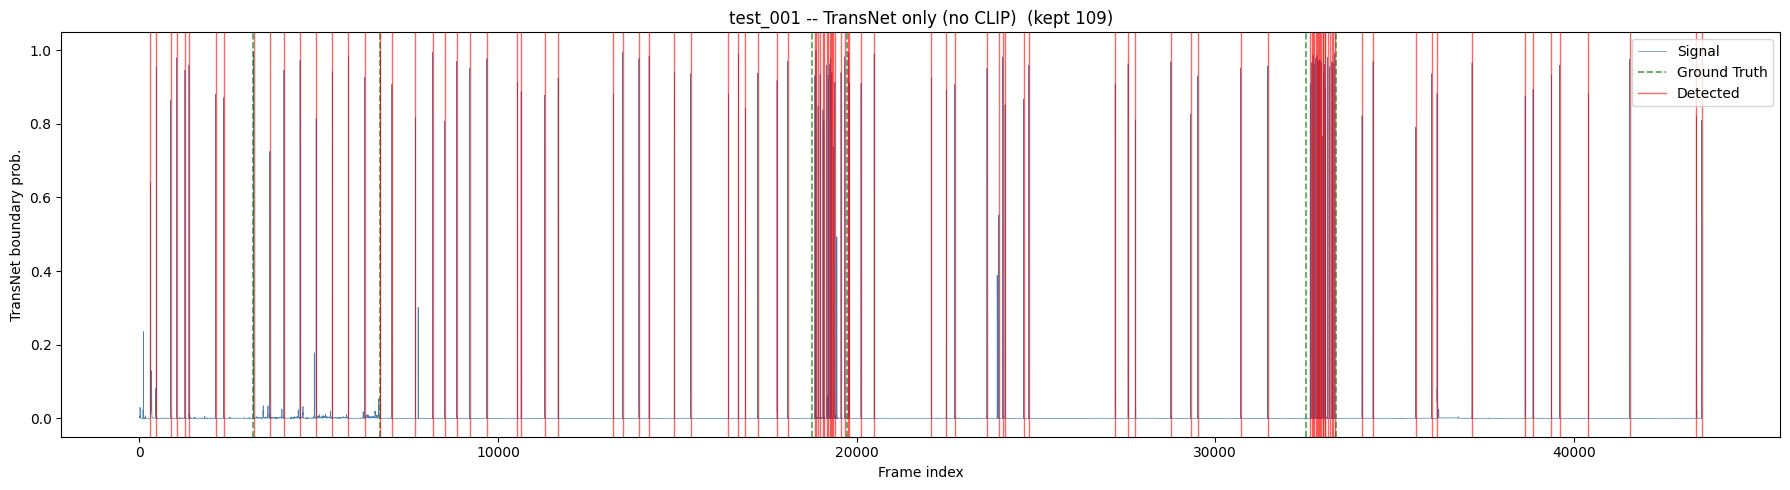

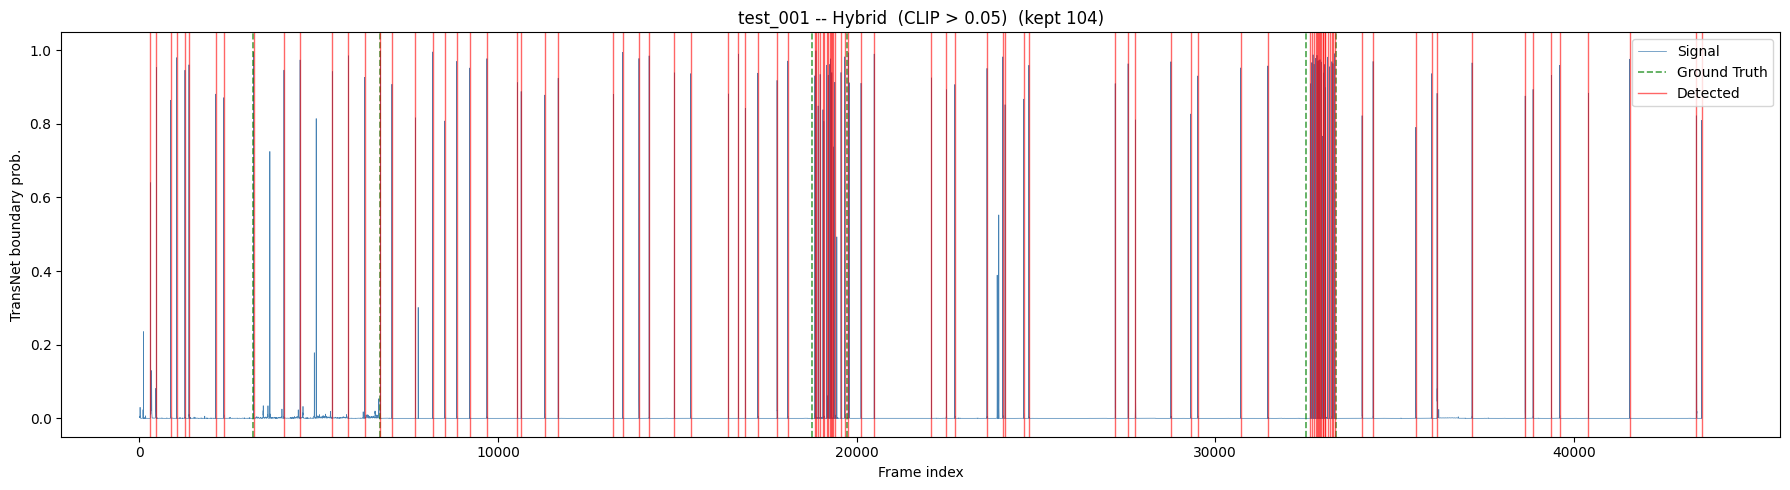

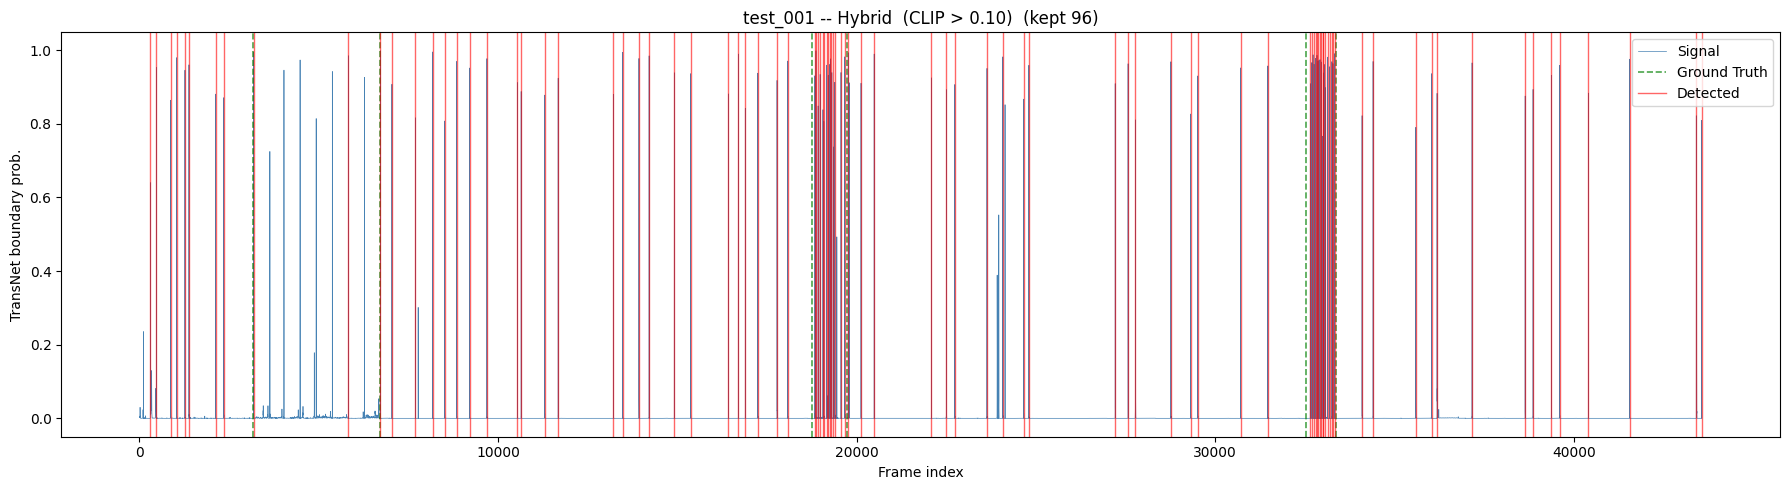

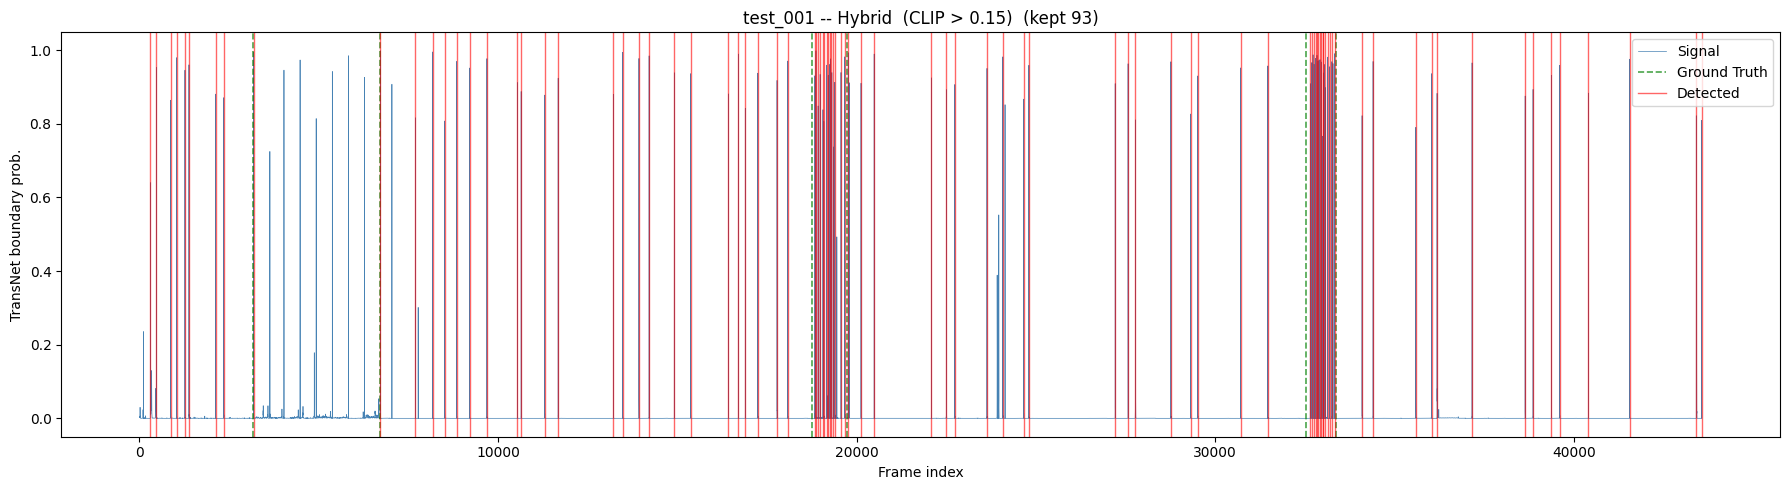

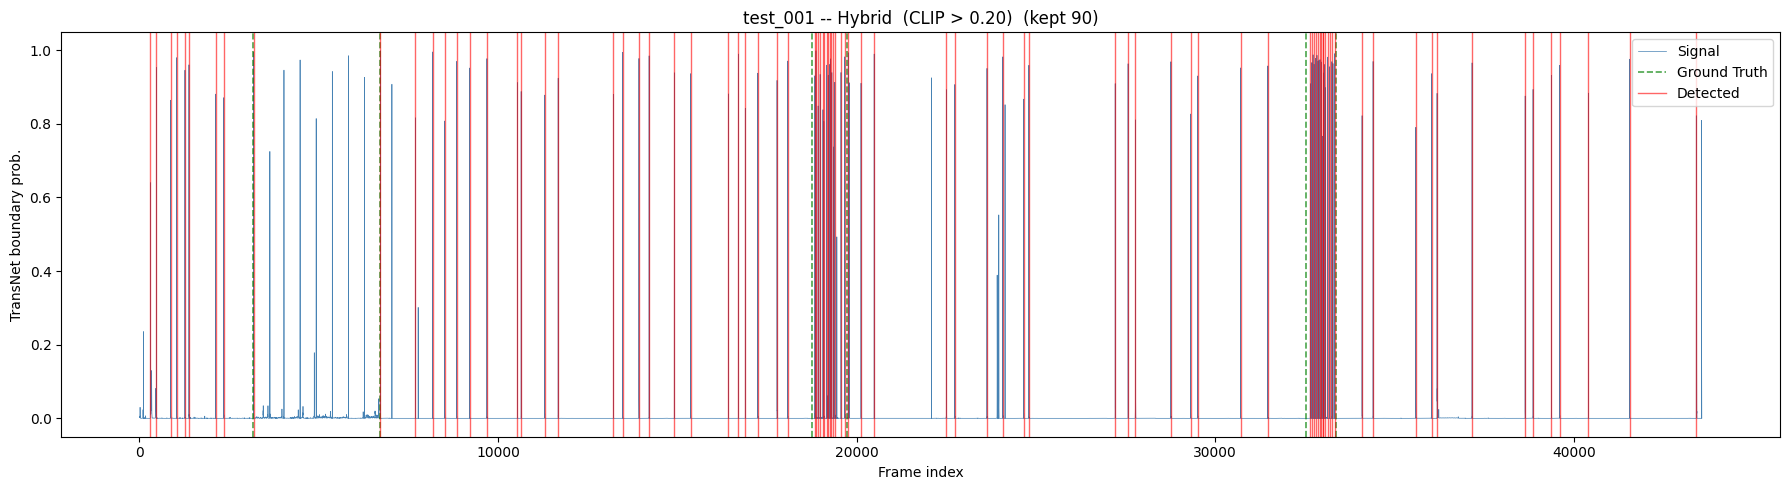

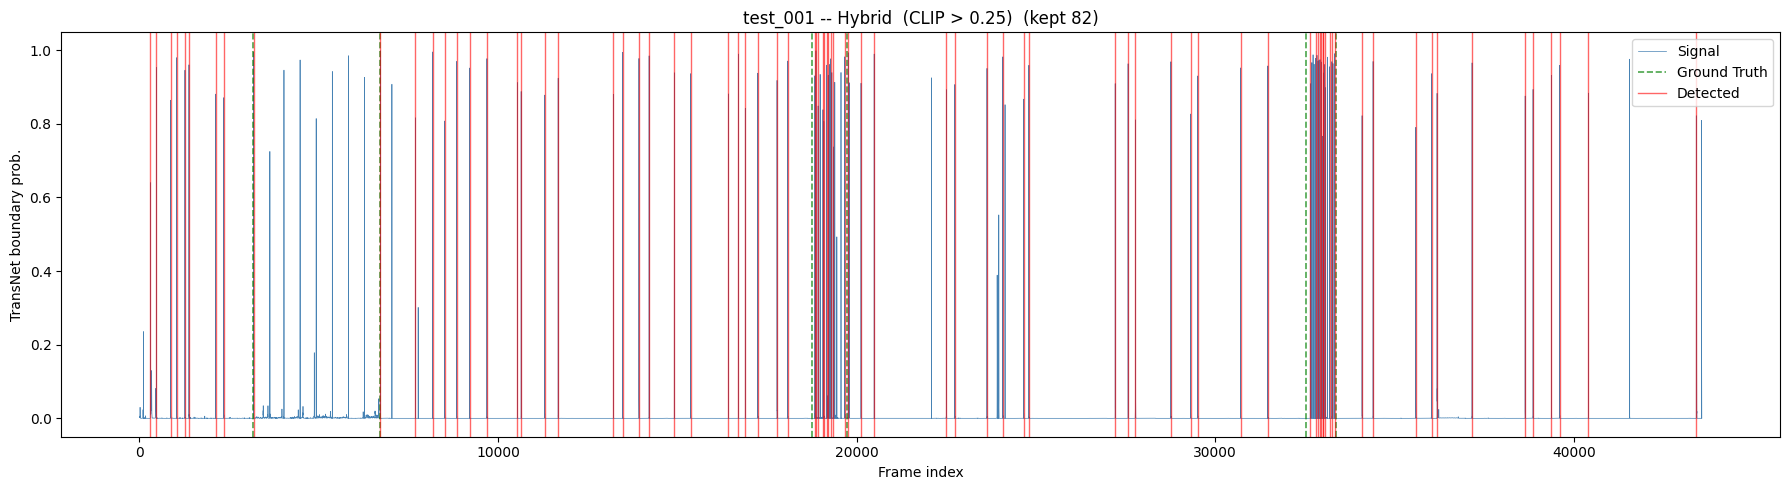

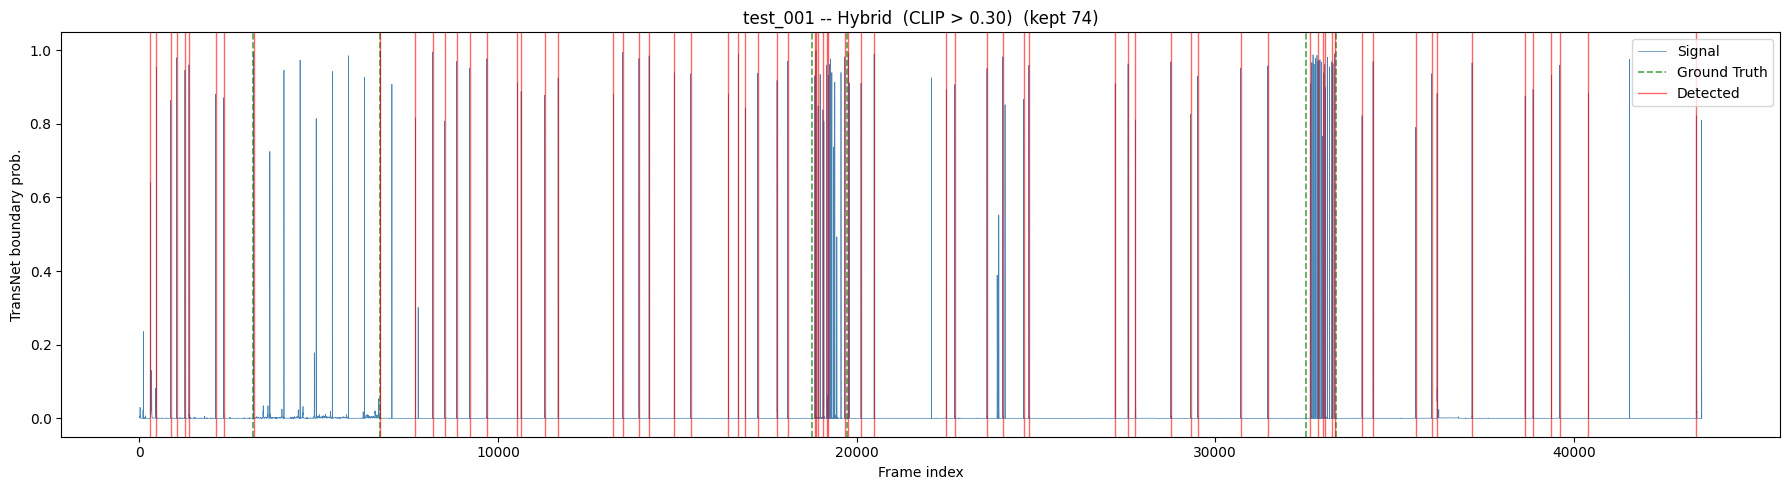

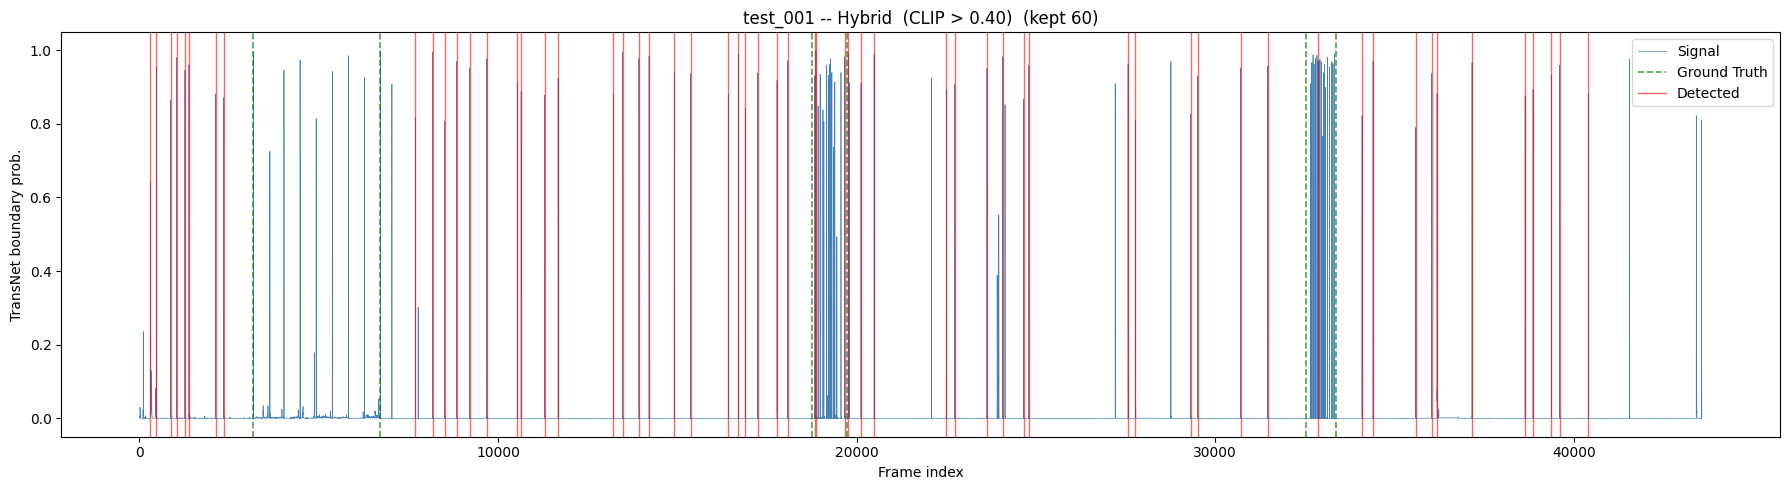

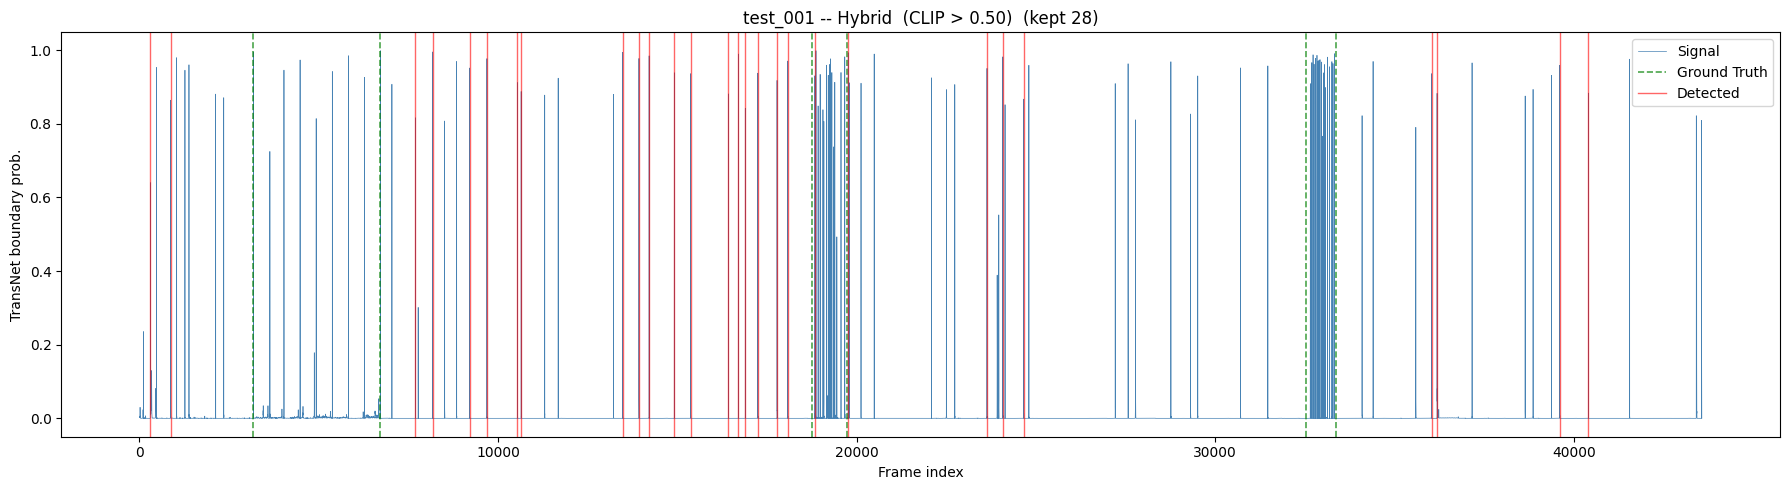

In [7]:
for label, thr, kept in configs:
    title = f"{VIDEO_NAME} -- {label}  (kept {len(kept)})"
    fig = plot_signal_with_boundaries(
        tn_scores,
        detected_frames=kept,
        ground_truth_frames=gt_boundaries,
        fps=fps,
        title=title,
        ylabel="TransNet boundary prob.",
        threshold=None,
    )
    plt.show()

## 7. Timeline comparison per configuration

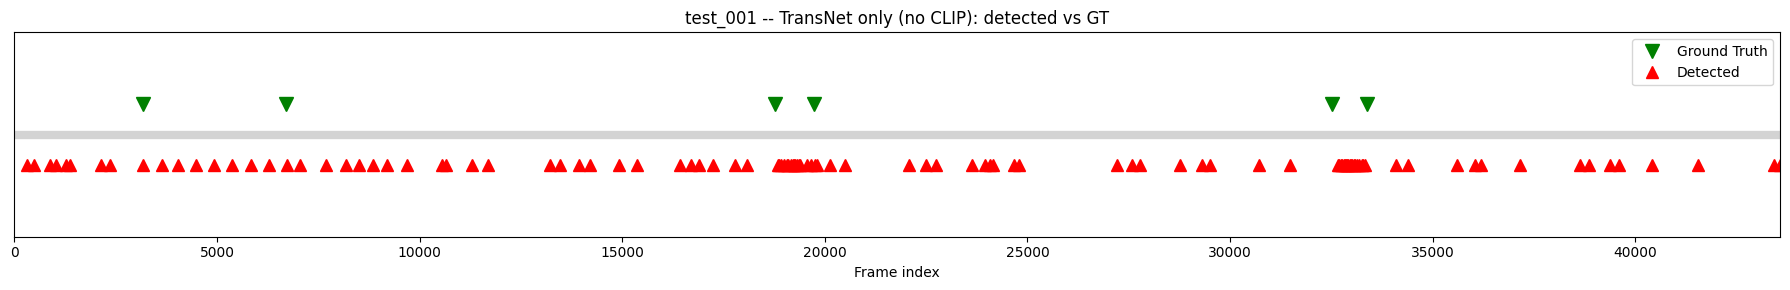

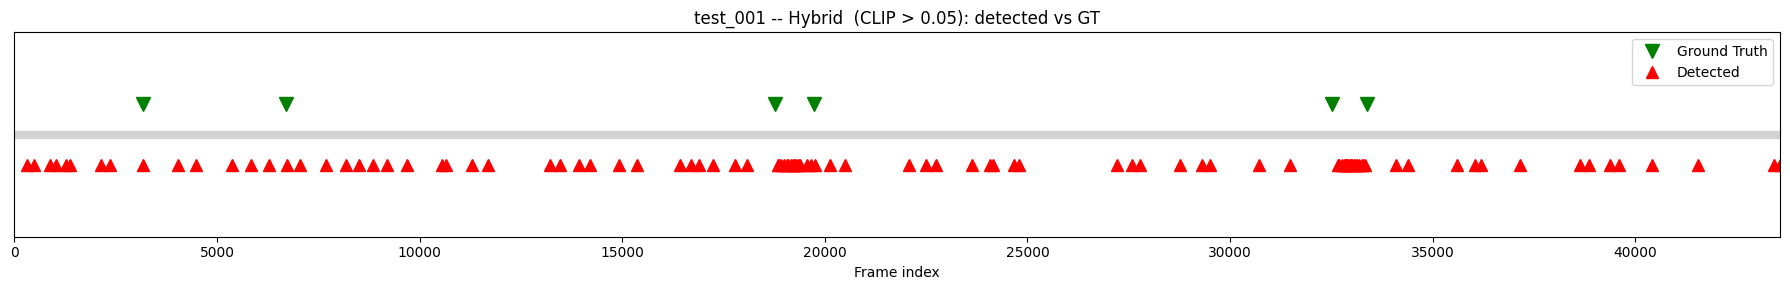

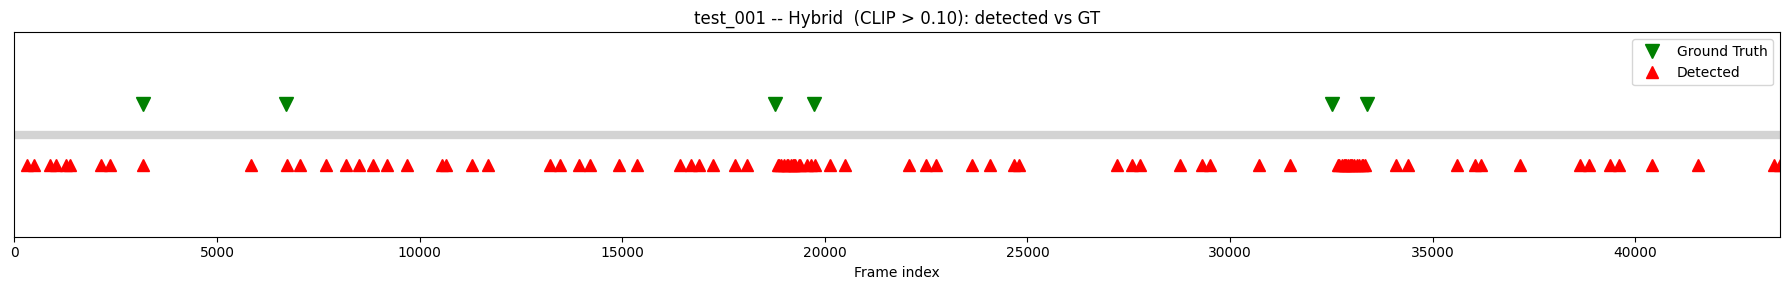

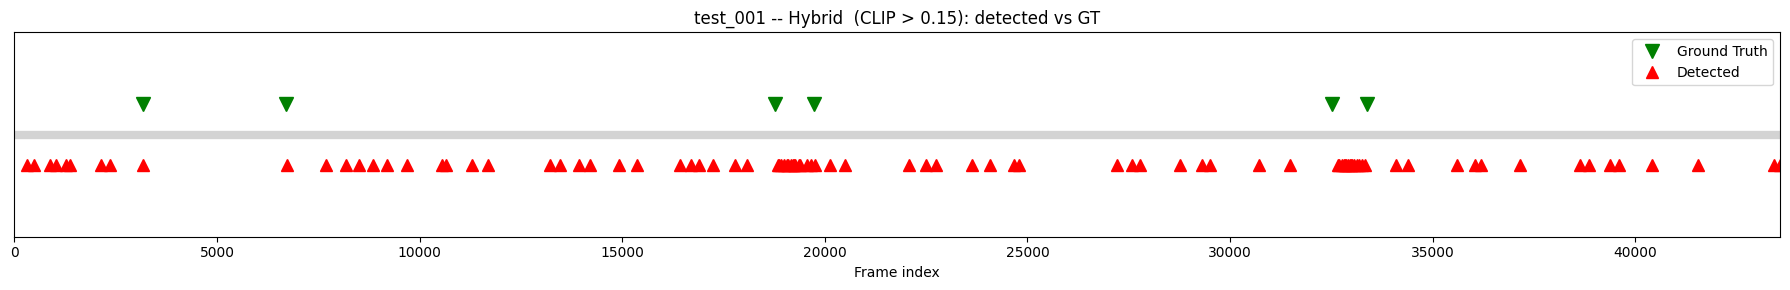

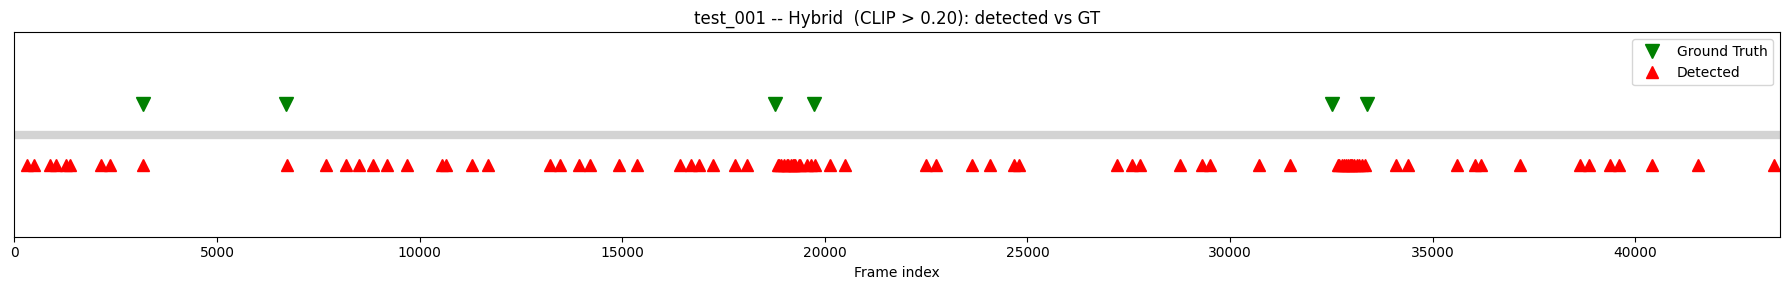

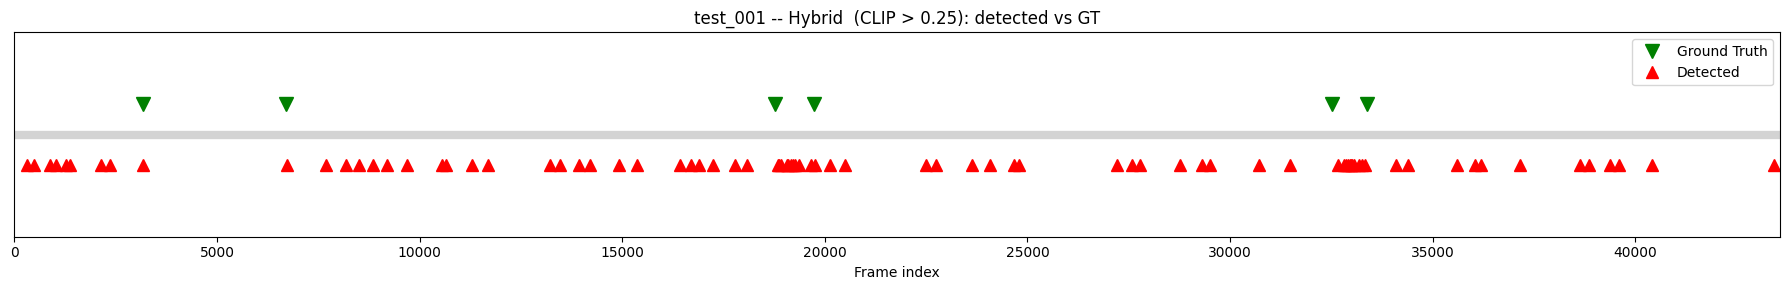

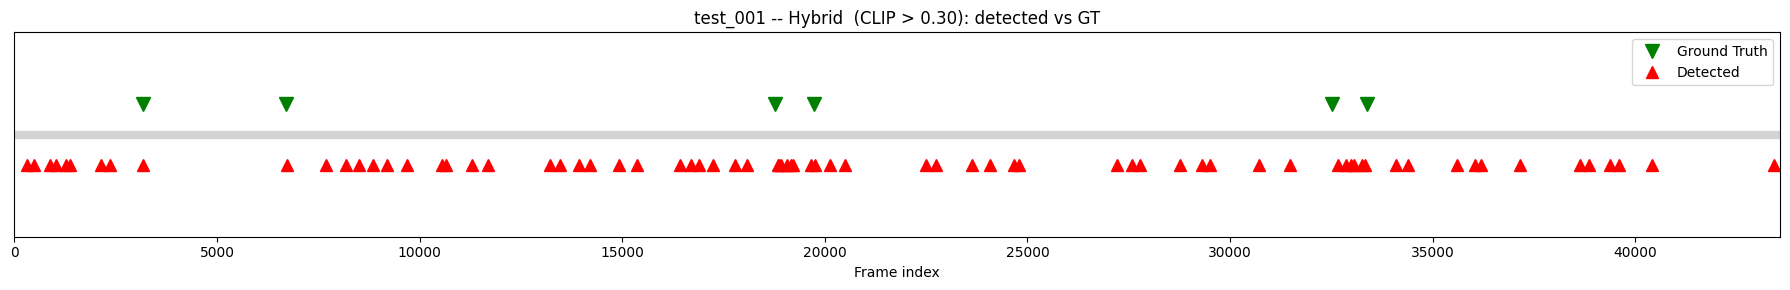

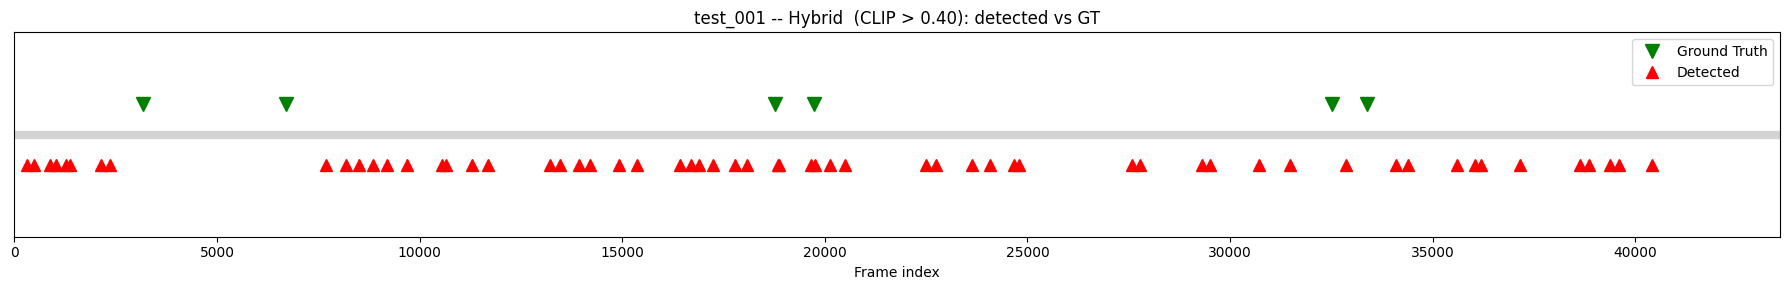

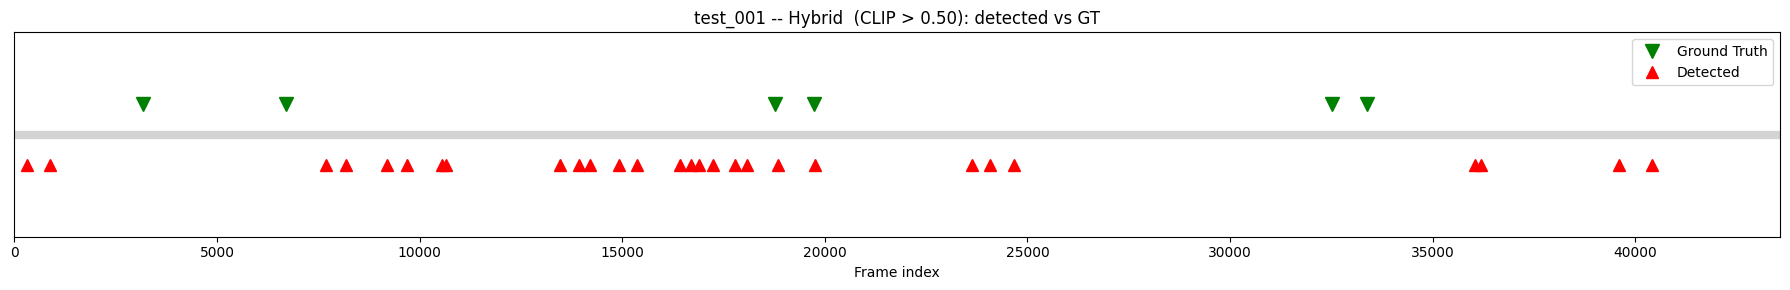

In [8]:
for label, thr, kept in configs:
    fig = plot_boundary_comparison(
        kept,
        gt_boundaries,
        total_frames,
        fps=fps,
        title=f"{VIDEO_NAME} -- {label}: detected vs GT",
    )
    plt.show()

## 8. Consecutive-candidate CLIP distances (diagnostic)

Plot the raw cosine distance between each candidate and the previous
one. Horizontal lines mark the swept thresholds. GT boundaries marked
on the x-axis so you can see which candidates are real ad transitions.

If most bars are below the threshold range, bump `POST_OFFSET` or try
averaging features over a window instead of a single frame.

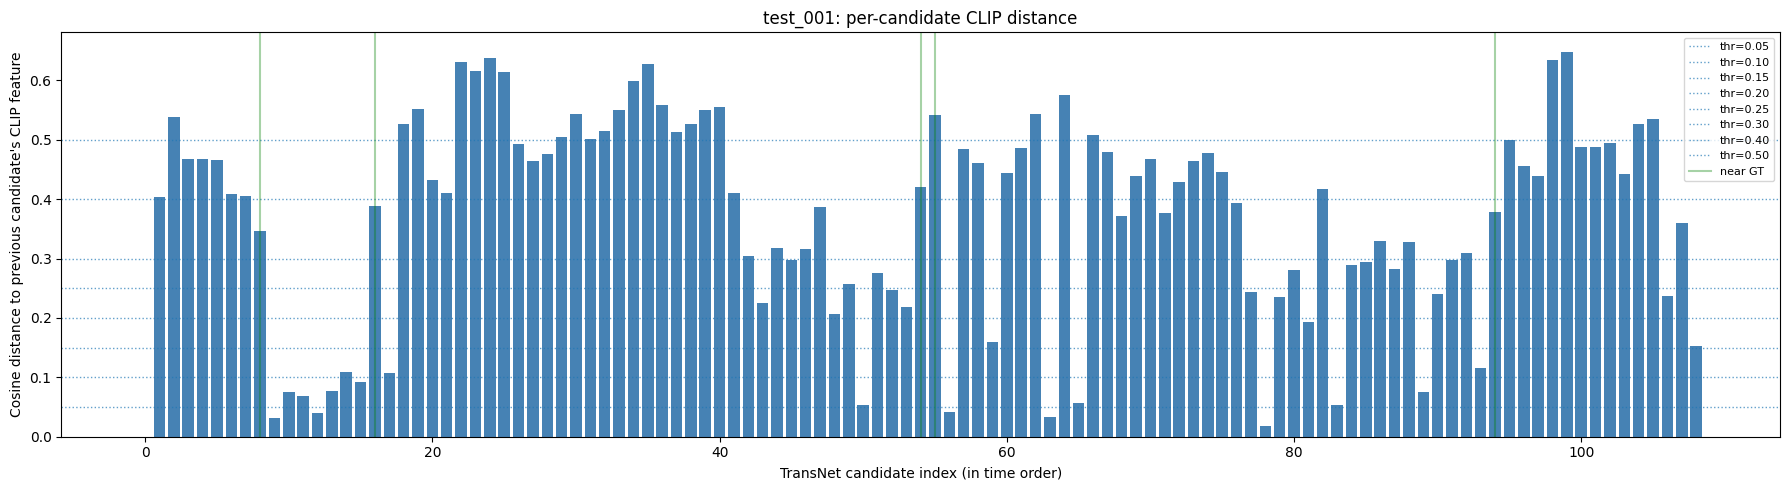

In [9]:
dists = [0.0]
for i in range(1, len(candidate_feats)):
    dists.append(1.0 - float(np.dot(candidate_feats[i - 1], candidate_feats[i])))

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(dists)), dists, color="steelblue", width=0.8)
for t in THRESHOLDS:
    ax.axhline(t, linestyle=":", linewidth=1, alpha=0.7, label=f"thr={t:.2f}")

# Mark which candidate indices are closest to a GT boundary
TOL = int(fps * 2)
for gi, g in enumerate(gt_boundaries):
    close = [i for i, c in enumerate(valid_candidates) if abs(c - g) <= TOL]
    for i in close:
        ax.axvline(i, color="green", alpha=0.35, linewidth=1.5,
                   label="near GT" if (gi == 0 and i == close[0]) else None)

ax.set_xlabel("TransNet candidate index (in time order)")
ax.set_ylabel("Cosine distance to previous candidate's CLIP feature")
ax.set_title(f"{VIDEO_NAME}: per-candidate CLIP distance")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

## 9. Notes

* At very low CLIP thresholds the filter is permissive -> output ~= raw
  TransNet.
* At very high thresholds, only visually distinctive transitions survive
  (usually content <-> ad).
* If no threshold gives a clean cut, the per-candidate distance plot
  (section 8) tells you whether GT transitions even *have* distinctive
  CLIP jumps -- if not, POST_OFFSET, frame averaging, or a different
  feature space is the next lever, not the threshold.